In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import logging
from tqdm import tqdm
from src.get_first_device import get_first_device
from src.get_seperated_curves import get_seperated_curves
from src.plot_curves import plot_curves
from src.encoder import Encoder
from src.decoder import Decoder
from src.set_logger import set_logger
from src.get_reconstruction_loss import get_reconstruction_loss
from src.mlp import Mlp
from src.pretrain_latent_diffusion import pretrain_latent_diffusion
from src.visualize_0 import visualize_0
from src.get_20_devices import get_20_devices
from src.torch_dataset import TorchDataset

CSV_FILE = "nmos_130nm_gaussian_l_vth_rds_50_devs_into_subth.csv"
SEP = " "
DEVICE_DIM = 1378
CURRENT_COL = 3
VOLTAGE_0_DIM = 53
VOLTAGE_1_DIM = 26
LEARNING_RATE = 2e-4
EPOCHS = 10_000
LOGGING_FILE = "logs.log"
LOGGER_LEVEL = logging.INFO 

dataframe = pd.read_csv(CSV_FILE, sep=SEP, header=None)
logger = set_logger(LOGGING_FILE, LOGGER_LEVEL)
torch_dataset = TorchDataset(
    dataframe,
    CURRENT_COL,
    DEVICE_DIM
)
train_loader = torch.utils.data.DataLoader(
    torch_dataset, batch_size=5
)
print(train_loader)
train_loader_iter = iter(train_loader)

raise KeyboardInterrupt

# Get first device data
first_device_data = get_first_device(dataframe, DEVICE_DIM, CURRENT_COL)
separated_curves = get_seperated_curves(first_device_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)

encoder = Encoder()
decoder = Decoder()

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE
)

first_device_data_tensor = torch.tensor(first_device_data, dtype=torch.float32)
mse_loss = torch.nn.MSELoss()

devices_20_data = get_20_devices(dataframe, DEVICE_DIM, CURRENT_COL) 
devices_20_data_tensor = torch.tensor(devices_20_data, dtype=torch.float32)

loss_list = []
for epoch in tqdm(range(EPOCHS)):
    for dev in devices_20_data_tensor:
        latent_data = encoder(dev)
        output_data = decoder(latent_data)

        loss = get_reconstruction_loss(output_data, first_device_data_tensor)
    
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if epoch % 100 == 0:
        logger.info(f"EPOCH: {epoch} LOSS: {loss.item()}")

tensor([[1.9893e-12, 3.4617e-12, 9.0675e-12,  ..., 7.6184e-05, 7.9046e-05,
         8.1907e-05],
        [5.0020e-11, 1.0826e-10, 2.3364e-10,  ..., 1.0107e-04, 1.0444e-04,
         1.0780e-04],
        [1.8400e-11, 3.9857e-11, 8.6282e-11,  ..., 9.1552e-05, 9.4713e-05,
         9.7870e-05],
        [5.1565e-11, 1.1158e-10, 2.4076e-10,  ..., 9.8355e-05, 1.0161e-04,
         1.0486e-04],
        [2.6229e-09, 5.4862e-09, 1.1298e-08,  ..., 1.3209e-04, 1.3581e-04,
         1.3952e-04]], dtype=torch.float64)
torch.Size([5, 1378])


KeyboardInterrupt: 

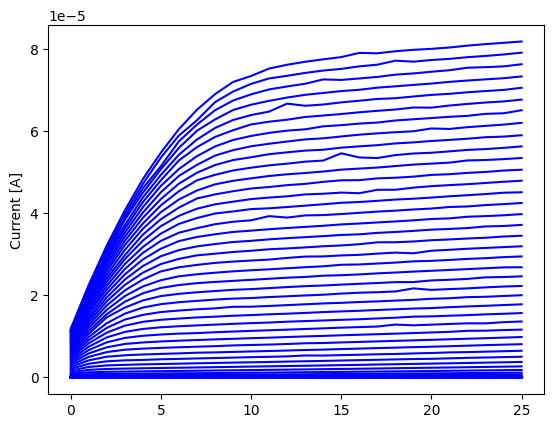

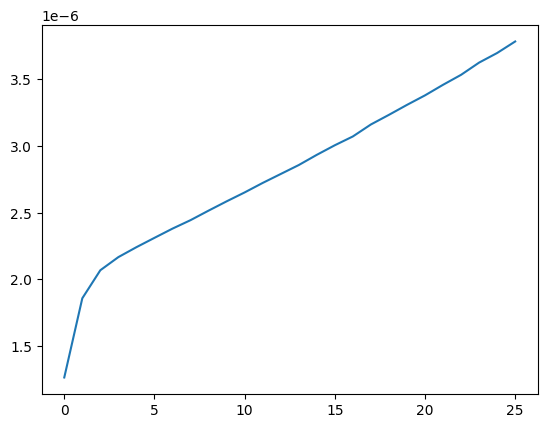

In [3]:
encoder.eval()
decoder.eval()

with torch.no_grad():
    encoded_data = encoder(first_device_data_tensor)
    decoded_data = decoder(encoded_data)

decoded_data = decoded_data.numpy()
separated_curves = get_seperated_curves(decoded_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
plt.plot(separated_curves[20])
plt.show()

In [ ]:
TIMESTEPS = 40
EPOCHS = 300_000
mlp_model = Mlp(TIMESTEPS)
diffusion_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=LEARNING_RATE
)
betas = (torch.sigmoid(torch.linspace(-18, 10, TIMESTEPS)) * (3e-1 - 1e-5) + 1e-5)
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

pretrain_latent_diffusion(mlp_model, encoder, first_device_data_tensor, diffusion_optimizer, EPOCHS, betas, alphas, alphas_bar, TIMESTEPS, logger)

In [ ]:
out_tensor = visualize_0(
    first_device_data_tensor,
    alphas_bar,
    betas,
    alphas,
    TIMESTEPS,
    mlp_model,
    encoder,
    decoder
)

out_numpy_data = out_tensor.numpy()

separated_curves = get_seperated_curves(out_numpy_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)